In [1]:
import pandas as pd
import json
import numpy as np
from torchmetrics.text import CharErrorRate
cer = CharErrorRate()

In [2]:
def search_data(file_name, df_truth):
    # print("file_name : ", file_name)
    for data_truth in df_truth.values.T[0]:
        try:
            json_truth_data = json.loads(data_truth)
            # print("json_truth_data : ", json_truth_data)
            if 'results' in json_truth_data.keys():
                if json_truth_data['results'][0]['file_name'] == file_name:
                    return data_truth
            # else:
            #     print(json_truth_data)
        except Exception as e:
            print(e)
    return None


def compare_classes_name_info_invoices(json_truth, json_predict):
    preds = []
    target = []
    keys = [
        'registration_location', 
        'business_type', 
        'business_code', 
        'regis_date', 
        'date_of_change'
    ]
    
    for key in keys:
        target.append(json_truth['results'][0]['extract_data']['classes_name_info_invoices'][key].strip().upper())
        preds.append(json_predict['results'][0]['extract_data']['classes_name_info_invoices'][key].strip().upper())
    
    # print("json_truth: ", json_truth)
    # print("json_predict: ", json_predict)
    # print()
    score = cer(preds, target)
    return score.numpy()


def compare_classes_name_info_company(json_truth, json_predict):
    keys = [
        'company_name', 
        'company_name_vi', 
        'company_name_en', 
        'short_name', 
        'company_address', 
        'company_phone', 
        'fax', 'email', 'website', 
        'business_entity', 'authorized_capital', 'authorized_capital_num', 'authorized_capital_char', 
        'par_value', 'total_share', 'shares_available_for_sale'
    ]
    
    preds = []
    target = []
    for key in keys:
        preds.append(json_predict['results'][0]['extract_data']['classes_name_info_company'][key].strip().upper())
        target.append(json_truth['results'][0]['extract_data']['classes_name_info_company'][key].strip().upper())
    
    # print(len(preds), len(target))
    score = cer(preds, target)
    return score.numpy()


def compare_item(json_truth_item, json_predict_item):
    keys = ['person_name', 
            'representative_address', 
            'household_address', 
            'nationality', 
            'share_type', 'number_of_shares', 'share_value', 
            'proportion', 
            'card_number', 
            'note', 
            'dob', 'issue_date', 'issued_at', 'card_type', 'gender', 'representative_title', 'ethnicity']
    preds = []
    target = []
    # print("json_truth_item : ", json_truth_item)
    # print("json_predict_item : ", json_predict_item)
    for key in keys:
        if key in json_truth_item.keys() and key in json_predict_item.keys():
            preds.append(json_truth_item[key].strip().upper())
            target.append(json_predict_item[key].strip().upper())
    # print(len(preds), len(target))
    score = cer(preds, target)
    return score.numpy()


def compare_classes_name_items(json_truth, json_predict, key_class='classes_name_key_legal_representative'):
    scores = []
    for item_predict in json_predict['results'][0]['extract_data'][key_class]:
        item_temp = None
        score_min = 99999
        # print("item_predict : ", item_predict)
        for item_truth in json_truth['results'][0]['extract_data'][key_class]:
            predict_label = item_predict['person_name'].strip().upper()
            truth_label = item_truth['person_name'].strip().upper()
            
            score = cer([predict_label], [truth_label])
            if  score.numpy() < score_min and score.numpy() < 0.1:
                item_temp = item_truth
                score_min = score.numpy()
        if item_temp is not None:
            # print("item_temp : ", item_temp)
            # print("item_predict : ", item_predict)
            # print("score_min : ", score_min)
            score_item = compare_item(json_truth_item=item_temp, json_predict_item=item_predict)
            # print("score_item : ", score_item)
            scores.append(score_item)
    # print("scores : ", scores)
    if len(scores) == 0:
        return 0
    # print(scores)
    return np.mean(scores)


def compare_responses(json_truth, json_predict):
    scores = []
    scores.append(compare_classes_name_info_invoices(json_truth, json_predict))
    scores.append(compare_classes_name_info_company(json_truth, json_predict))
    scores.append(compare_classes_name_items(json_truth, json_predict, key_class='classes_name_key_legal_representative'))
    scores.append(compare_classes_name_items(json_truth, json_predict, key_class='classes_name_key_contributior'))
    scores.append(compare_classes_name_items(json_truth, json_predict, key_class='classes_name_key_company_owner_info'))
    return np.mean(scores)
    

In [3]:
def get_cer_score(df_truth, df_filler_data, model_name="gpt"):
    score_image_data, score_text_data, score_imgxtext_data, score_with_pp, score_new = [], [], [], [], []
    df_new = pd.read_csv("/u01/manhquang/dataset/ekyb/eval_pipline/responses_2025-12-29-flash-2.5.csv", usecols=['LLM(New)'], sep="\t")
    for i, (llm_image, llm_text, llm_imgxtext, llm_without_pp) in enumerate(df_filler_data.values):
        try:
            # print(i)
            # print(llm_image)
            llm_image_data = json.loads(llm_image)
            llm_text_data = json.loads(llm_text)
            llm_imgxtext_data = json.loads(llm_imgxtext)
            llm_without_pp = json.loads(llm_without_pp)
            # print(df_new.values[i])
            llm_new = json.loads(df_new.values[i][0])
            # print(llm_image_data)
            # print(llm_text_data)
            # print(llm_imgxtext_data)
            if len(llm_new.keys()) == 1:
                continue
            
            if llm_image_data['results'][0]['file_name'] == llm_text_data['results'][0]['file_name'] and \
                llm_image_data['results'][0]['file_name'] == llm_imgxtext_data['results'][0]['file_name'] \
                and llm_image_data['results'][0]['file_name'] == llm_new['results'][0]['file_name']:
                    
                json_truth_data = json.loads(search_data(file_name=llm_image_data['results'][0]['file_name'], df_truth=df_truth))
            
                score_image_data.append(compare_responses(json_truth=json_truth_data, json_predict=llm_image_data))
                score_text_data.append(compare_responses(json_truth=json_truth_data, json_predict=llm_text_data))
                score_imgxtext_data.append(compare_responses(json_truth=json_truth_data, json_predict=llm_imgxtext_data))
                score_with_pp.append(compare_responses(json_truth=json_truth_data, json_predict=llm_without_pp))
                score_new.append(compare_responses(json_truth=json_truth_data, json_predict=llm_new))
            else:
                print("sai tên")
                print(llm_image)
                # print(llm_text)
                # print(llm_imgxtext)
                
        except Exception as e:
            print("message error: ", e)
            # print("llm_image_data: ", llm_image_data)
            # print("llm_text_data: ", llm_text_data)
            # print("llm_imgxtext_data: ", llm_imgxtext_data)
            pass
            
    print("\nCER llm_image : ", (1 - np.mean(score_image_data))*100)
    print("\nCER llm_new : ", (1 - np.mean(score_new))*100, np.mean(score_new))
    print("CER score_text_data : ", (1 - np.mean(score_text_data))*100)
    print("CER score_imgxtext_data : ", (1 - np.mean(score_imgxtext_data))*100)
    print("CER score_with_pp : ", (1 - np.mean(score_with_pp))*100)
    return [model_name, np.mean(score_image_data), np.mean(score_text_data), np.mean(score_imgxtext_data), np.mean(score_with_pp)]

In [16]:
def cer_score(df_truth, df_filler_data, model_name="gpt"):
    score_new = []
    total_pages = 0
    for i, (path, results) in enumerate(df_filler_data.values):
        try:
            llm_results = json.loads(results)
            total_pages += llm_results['page_numbers']
            if len(llm_results.keys()) == 1:
                print("path: ", path)
                print("llm_results: ", llm_results)
                continue

            json_truth_data = json.loads(search_data(file_name=llm_results['results'][0]['file_name'], df_truth=df_truth))
            score_new.append(compare_responses(json_truth=json_truth_data, json_predict=llm_results))
                
        except Exception as e:
            # print(llm_results['detail']['page_numbers'])
            total_pages += llm_results['detail']['page_numbers']
            print("message error: ", e)
            pass
            
    print(f"\nArc {model_name} CER score : ACC {round((1 - np.mean(score_new)) * 100, 3)} - CER: {round(np.mean(score_new), 3)}")
    print("Total Page: ", total_pages)
    return [model_name, np.mean(score_new)]

In [17]:
truth_path = "/u01/manhquang/dataset/ekyb/eval_pipline/df_full_250820_recheck_2.csv"
df_truth = pd.read_csv(truth_path, sep=",", usecols=['json_truth'])

llm_path = {
    # "flash_2_0": "/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-01-06-gemini-2.0-flash.csv",
    # "flash_2_5": "/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-01-06-gemini-2.5-flash_v2.csv",
    # "mix_542": "/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-01-29_mix_542.csv",
    # "mix_545": "/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-01-29_mix_545.csv",
    # "mix_242": "/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-01-29_mix_242.csv",
    "mix_778": "/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-07-16.csv"
}

for key in llm_path.keys():
    df_filler_data = pd.read_csv(llm_path[key], sep="\t")
    print(cer_score(df_truth, df_filler_data, model_name=key))

message error:  'page_numbers'
message error:  'page_numbers'
message error:  'page_numbers'
message error:  'page_numbers'
message error:  'page_numbers'
message error:  'page_numbers'

 Arc mix_778 CER score : ACC 91.909 - CER: 0.081
Total Page:  110
['mix_778', 0.08090712558095382]


In [ ]:
import os

gpt_pred = {
    # 'gpt4o': "/u01/manhquang/dataset/ekyb/eval_pipline/responses_250908-gpt4o.csv",
    # 'gpt4o-mini': '/u01/manhquang/dataset/ekyb/eval_pipline/responses_250905-gpt4o-mini.csv',
    # 'gpt5': "/u01/manhquang/dataset/ekyb/eval_pipline/responses_250903-gpt5.csv",
    # "gpt5-mini": "/u01/manhquang/dataset/ekyb/eval_pipline/responses_250905-gpt5-mini.csv",
    'gemini-2.5-pro': "/u01/manhquang/dataset/ekyb/eval_pipline/responses_251031-gemini-2.5-pro.csv",
    # 'gemini-(2.0+2.5)-flash': "/u01/manhquang/dataset/ekyb/eval_pipline/responses_2025-12-29-flash-2.5.csv"
}

gpt_cer_score = {
    "models": gpt_pred.keys(),
}

# GPT4o
truth_path = "/u01/manhquang/dataset/ekyb/eval_pipline/df_full_250820_recheck_2.csv"
df_truth = pd.read_csv(truth_path, sep=",", usecols=['json_truth'])

scores = []
for key in gpt_pred.keys():

    df_filler_data = pd.read_csv(gpt_pred[key], sep="\t")
    # print(df_filler_data)
    print("\nOUTPUT : ", key)
    cer_score = get_cer_score(df_truth=df_truth, df_filler_data=df_filler_data, model_name=key)
    print(cer_score)
    scores.append(cer_score)

scores = np.array(scores)
scores

In [4]:
df_flash_2_0 = pd.read_csv("/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-01-06-gemini-2.0-flash.csv", sep="\t")
df_flash_2_0.head()

,file_name,LLM_arc_new
0,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""ca1d030c-eab3-11f0-b059-b8ca3af3851a""..."
1,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""d1615096-eab3-11f0-b059-b8ca3af3851a""..."
2,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""d6fdd2ae-eab3-11f0-b059-b8ca3af3851a""..."
3,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""dc6df8f4-eab3-11f0-b059-b8ca3af3851a""..."
4,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""e1dee096-eab3-11f0-b059-b8ca3af3851a""..."


In [5]:
df_flash_2_5 = pd.read_csv("/u01/manhquang/dataset/ekyb/eval_pipline/responses_2026-01-06-gemini-2.5-flash_v2.csv", sep="\t")
df_flash_2_5.head()

,file_name,LLM_arc_new
0,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""768d500a-eaa6-11f0-858b-b8ca3af3851a""..."
1,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""823b09c4-eaa6-11f0-858b-b8ca3af3851a""..."
2,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""8c5712c2-eaa6-11f0-858b-b8ca3af3851a""..."
3,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""9c3837ac-eaa6-11f0-858b-b8ca3af3851a""..."
4,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""a6213fd4-eaa6-11f0-858b-b8ca3af3851a""..."


In [6]:
df_merge = df_flash_2_5.merge(df_flash_2_0, how='inner', on='file_name')
df_merge.head()

,file_name,LLM_arc_new_x,LLM_arc_new_y
0,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""768d500a-eaa6-11f0-858b-b8ca3af3851a""...","{""uuid"":""ca1d030c-eab3-11f0-b059-b8ca3af3851a""..."
1,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""823b09c4-eaa6-11f0-858b-b8ca3af3851a""...","{""uuid"":""d1615096-eab3-11f0-b059-b8ca3af3851a""..."
2,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""8c5712c2-eaa6-11f0-858b-b8ca3af3851a""...","{""uuid"":""d6fdd2ae-eab3-11f0-b059-b8ca3af3851a""..."
3,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""9c3837ac-eaa6-11f0-858b-b8ca3af3851a""...","{""uuid"":""dc6df8f4-eab3-11f0-b059-b8ca3af3851a""..."
4,/u01/manhquang/dataset/ekyb/eval_pipline/eval_...,"{""uuid"":""a6213fd4-eaa6-11f0-858b-b8ca3af3851a""...","{""uuid"":""e1dee096-eab3-11f0-b059-b8ca3af3851a""..."


In [ ]:
import pandas as pd
df = pd.read_csv("/u01/manhquang/dataset/ekyb/eval_pipline/responses_251031-gemini-2.5-pro.csv", sep="\t")
df['LLM(Images_without_PP)']

In [ ]:
df_gpt_series = pd.DataFrame(scores, columns=['models','LLM(Images)', 'LLM(Texts)', 'LLM(Images,Texts)'])
df_gpt_series.to_csv("/u01/manhquang/dataset/ekyb/eval_pipline/output/MLLMs_series_251006.csv")
df_gpt_series

In [11]:
import numpy as np 


def extract_info_langfuse(df_langfuse):
    df_langfuse_llm_image = df_langfuse[df_langfuse['name'] == 'LLM(Images)-generation']
    avg_cost_llmimgs = np.mean(df_langfuse_llm_image['calculatedTotalCost'].values)
    avg_latency_llmimgs = np.mean(df_langfuse_llm_image['latency'].values)

    df_langfuse_llm_text = df_langfuse[df_langfuse['name'] == 'LLM(Texts)-generation']
    avg_cost_llmtxts = np.mean(df_langfuse_llm_text['calculatedTotalCost'].values)
    avg_latency_llmtxts = np.mean(df_langfuse_llm_text['latency'].values) # avg OCR system process befor call LLM

    df_langfuse_llm_imagextext = df_langfuse[df_langfuse['name'] == "\"LLM(Images,Texts)-generation\""]
    avg_cost_llmtxtximgs = np.mean(df_langfuse_llm_imagextext['calculatedTotalCost'].values)
    avg_latency_llmtxtximgs = np.mean(df_langfuse_llm_imagextext['latency'].values) # avg OCR system process befor call LLM

    df_data = pd.DataFrame(data={
        "Input": ['Image', 'Text', "ImagexText"],
        "avg_cost": [avg_cost_llmimgs, avg_cost_llmtxts, avg_cost_llmtxtximgs],
        "avg_latency": [avg_latency_llmimgs, avg_latency_llmtxts, avg_latency_llmtxtximgs],
    })
    return df_data

        Input  avg_cost_x  avg_latency_x  cer_gpt4o  avg_cost_y  \
0       Image    0.035872      37.171667   0.083230    0.009158   
1        Text    0.029510      21.093280   0.110811    0.001087   
2  ImagexText    0.051969      37.142844   0.076151    0.009744   

   avg_latency_y  cer_gpt4o_mini  
0      24.445128        0.270349  
1      15.896197        0.111152  
2      33.442377        0.111417  


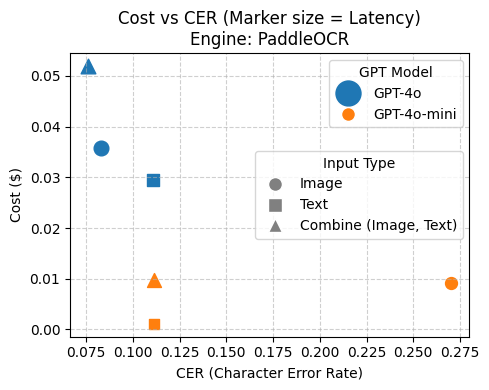

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ====== Load dữ liệu ======
file1 = "/u01/manhquang/dataset/ekyb/eval_pipline/output/gpt4o.csv"
file2 = "/u01/manhquang/dataset/ekyb/eval_pipline/output/gpt4o-mini.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Đổi tên để đồng bộ
df1 = df1.rename(columns={"Input_call_LLM": "Input"})
df2 = df2.rename(columns={"Input_call_LLM": "Input"})

# Gộp hai bảng theo Input
merged = pd.merge(df1, df2, on="Input", how="inner")

print(merged)

# ====== Marker cho loại input ======
markers = {
    "Image": "o",        # tròn
    "Text": "s",         # vuông
    "ImagexText": "^"    # tam giác
}

# Màu cho model
colors = {
    "GPT-4o": "#1f77b4",       # xanh lam
    "GPT-4o-mini": "#ff7f0e"   # cam đỏ
}

plt.figure(figsize=(5,4))

# ====== Vẽ scatter ======
for i, row in merged.iterrows():
    # GPT-4o
    plt.scatter(
        row["cer_gpt4o"], row["avg_cost_x"], 
        s=row["avg_latency_x"] * 3, 
        c=colors["GPT-4o"], marker=markers[row["Input"]], label="GPT-4o"
    )

    # GPT-4o-mini
    plt.scatter(
        row["cer_gpt4o_mini"], row["avg_cost_y"], 
        s=row["avg_latency_y"] * 3, 
        c=colors["GPT-4o-mini"], marker=markers[row["Input"]], label="GPT-4o-mini"
    )

# ====== Legend tuỳ chỉnh ======
# Legend cho GPT Model (màu sắc)
legend_models = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=colors["GPT-4o"], markersize=20, label="GPT-4o"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=colors["GPT-4o-mini"], markersize=10, label="GPT-4o-mini")
]

# Legend cho Input (marker shape)
legend_inputs = [
    Line2D([0],[0], marker=markers["Image"], color="w", markerfacecolor="gray", markersize=10, label="Image"),
    Line2D([0],[0], marker=markers["Text"], color="w", markerfacecolor="gray", markersize=10, label="Text"),
    Line2D([0],[0], marker=markers["ImagexText"], color="w", markerfacecolor="gray", markersize=10, label="Combine (Image, Text)")
]

# Đặt 2 legend tách biệt
first_legend = plt.legend(handles=legend_models, title="GPT Model", loc="upper right")
plt.gca().add_artist(first_legend)
plt.legend(handles=legend_inputs, title="Input Type", loc="center right")

# ====== Trục & Tiêu đề ======
plt.xlabel("CER (Character Error Rate)")
plt.ylabel("Cost ($)")
plt.title("Cost vs CER (Marker size = Latency)\nEngine: PaddleOCR")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
